# Validation of the ZIP-Load Models

## 0 Imports and Predefinitions

In [1]:
# %matplotlib inline
# import ipympl

import numpy as np
import os
import sys
import pandas as pd

# Set a fixed seed for reproducibility
np.random.seed(42)
if "torch" in sys.modules:
    import torch

    torch.manual_seed(42)

parent = os.path.abspath("/Users/maxikoehler/Documents/GitHub/diffpssi-ma-kohler/")
sys.path.insert(1, parent)
sys.path.append(
    str(os.path.dirname(os.path.dirname(os.path.abspath("zip-load_validation.ipynb"))))
)

import matplotlib.pyplot as plt
import matplotlib as mpl
from tools import *

from src.diffpssi.power_sim_lib.simulator import PowerSystemSimulation as Pss
from src.diffpssi.power_sim_lib.simulator import Recorder
from tools.calcs import *

Using numpy as backend


In [2]:
BACKEND = "numpy"  # 'torch' or 'numpy'
DEFAULT_DEVICE = "cpu"  # 'cuda' or 'cpu'

if os.environ.get("DIFFPSSI_SIM_BACKEND") is not None:
    BACKEND = os.environ.get("DIFFPSSI_SIM_BACKEND")

if BACKEND == "torch":
    import torch
    import numpy

    torch.pi = numpy.pi
    print("Using torch as backend")
    if torch.cuda.is_available() and (
        DEFAULT_DEVICE == "cuda" or DEFAULT_DEVICE == "gpu"
    ):
        torch.set_default_device("cuda")
        print("Using torch with CUDA on GPU")
    else:
        print("Using torch on CPU")

elif BACKEND == "numpy":
    import numpy as torch

    torch.tensor = torch.array
    torch.unsqueeze = torch.expand_dims
    print("Using numpy as backend")
else:
    raise ValueError("No backend specified")

parallel_sims = 1

Using numpy as backend


In [3]:
def load(p_load=400, q_load=0, model="Z"):
    """
    Loads the grid data of the IBB transformer model.
    Returns: The grid data in form of a dictionary.

    """
    return {
        "base_mva": 2200,
        "f": 60,
        "slack_bus": "Bus 0",
        "base_voltage": 100,
        "busses": [
            ["name", "V_n"],
            ["Bus 0", 10],
            ["Bus 1", 100],
            # ['Bus 2', 100],
        ],
        "transformers": [
            [
                "type",
                "control",
                "name",
                "from_bus",
                "to_bus",
                "S_n",
                "V_n_from",
                "V_n_to",
                "R",
                "X",
                "theta",
            ],
            ["simple", "oltc", "T1", "Bus 0", "Bus 1", 2200, 10, 100, 0, 0.15, 0],
        ],
        "generators": {
            "GEN": [
                [
                    "name",
                    "bus",
                    "S_n",
                    "V_n",
                    "P",
                    "V",
                    "H",
                    "D",
                    "X_d",
                    "X_q",
                    "X_d_t",
                    "X_q_t",
                    "X_d_st",
                    "X_q_st",
                    "T_d0_t",
                    "T_q0_t",
                    "T_d0_st",
                    "T_q0_st",
                ],
                [
                    "G1",
                    "Bus 0",
                    2200,
                    10,
                    -1998,
                    1,
                    3.5,
                    0,
                    1.81,
                    1.76,
                    0.3,
                    0.65,
                    0.23,
                    0.23,
                    8.0,
                    1,
                    0.03,
                    0.07,
                ],
            ]
        },
        "loads": {
            "ZIP": [
                ["name", "bus", "P", "Q", "model"],
                ["L1", "Bus 1", p_load, q_load, model],
            ],
        },
    }

In [4]:
def record_dict(simulation, call=False):
    record_dict = {
        "Bus 0: voltage magnitude": simulation.busses[0].get_value("voltage_mag"),
        "Bus 1: voltage magnitude": simulation.busses[1].get_value("voltage_mag"),
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

## 1 Looking at a constant Z model

### 1.1 Sim Set-Up and Run

In [5]:
sim = Pss(
    parallel_sims=parallel_sims,
    sim_time=20,
    time_step=0.005,
    solver="heun",
    grid_data=load(),
)

sim.add_param_event(
    1, sim.busses[1].models[0], "p_soll_mw", 2 * sim.busses[1].models[0].p_soll_mw
)
rec = Recorder(sim=sim, recorder_dict=record_dict)
sim.set_record_function(rec.record_fun)
record_list = rec.record_list()
t, recorder = sim.run()

print(f"\nLast voltage magnitude at busses: {recorder[0, -1, :]}")

Load flow finished in 3 iterations with error 1.28e-13 in 0.0074 seconds


100%|██████████| 4001/4001 [00:00<00:00, 4772.12it/s]

Dynamic simulation finished in 0.87 seconds

Last voltage magnitude at busses: [0.87359032 0.87229173]


### 1.2 Inspection

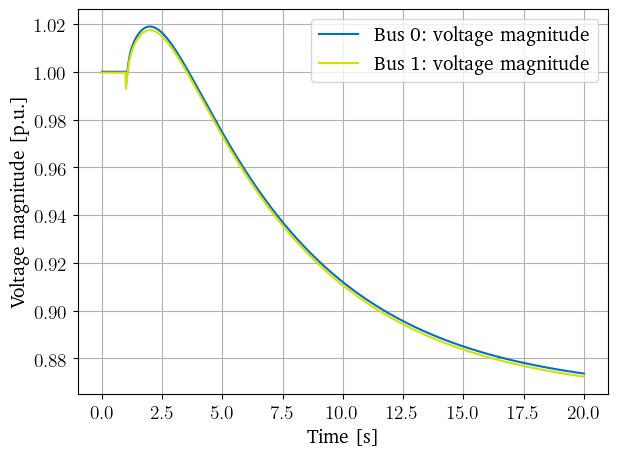

In [6]:
plt.figure()
for i in range(len(record_list)):
    plt.plot(t, recorder[0, :, i], label=record_list[i])

plt.xlabel("Time [s]")
plt.ylabel("Voltage magnitude [p.u.]")
plt.legend()
plt.grid()

plt.savefig("./data/time_series_z_load.pdf")
plt.show()

### 1.3 Loading PF Data

In [7]:
data_pf_cZ = pd.read_csv(
    "./data/variation_load/gen_z-load-inc400-800.csv", sep=";", dtype=float
)
data_pf_cZ.rename(
    columns={
        "Time in s": "t",
        "Deviation of the El. Frequency in Hz": "Frequency Deviation",
        "Electrical Frequency in p.u.": "Frequency",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
    },
    inplace=True,
)
data_pf_cZ.set_index("t", inplace=True)
data_pf_cZ.drop(columns=["Frequency Deviation", "Frequency"], inplace=True)

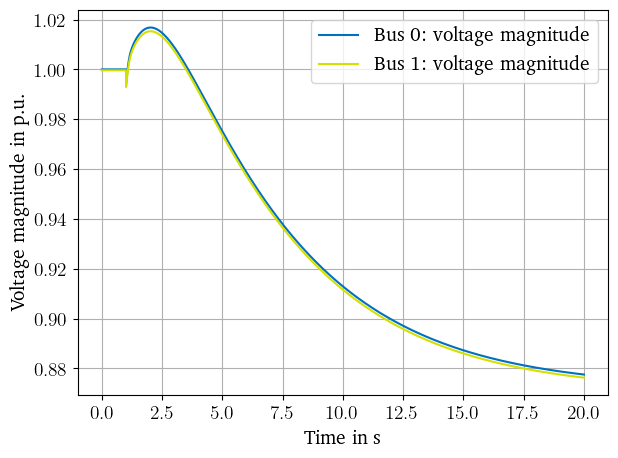

In [8]:
plt.figure()
for i in range(len(data_pf_cZ.columns)):
    plt.plot(
        data_pf_cZ.index.values, data_pf_cZ.iloc[:, i], label=data_pf_cZ.columns[i]
    )

plt.xlabel("Time in s")
plt.ylabel("Voltage magnitude in p.u.")
plt.legend()
plt.grid()

plt.show()

### 1.4 Comparison

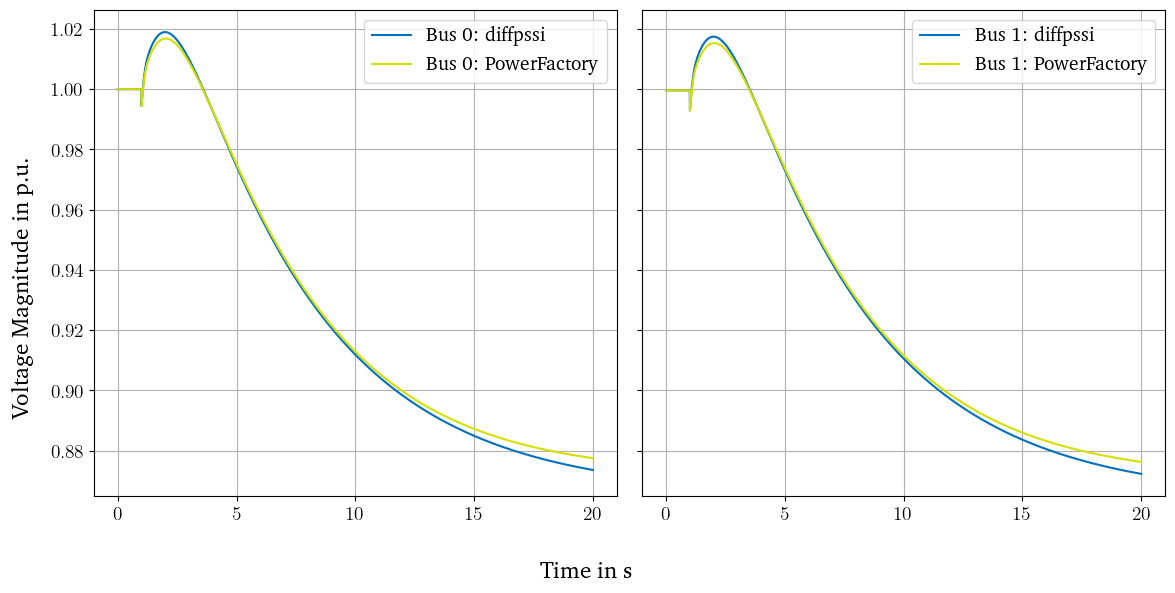

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax[0].plot(t, recorder[0, :, 0], label="Bus 0: diffpssi")
ax[0].plot(t, data_pf_cZ.iloc[:, 0], label="Bus 0: PowerFactory")
ax[0].legend()
ax[0].grid()

ax[1].plot(t, recorder[0, :, 1], label="Bus 1: diffpssi")
ax[1].plot(t, data_pf_cZ.iloc[:, 1], label="Bus 1: PowerFactory")
ax[1].legend()
ax[1].grid()

fig.supxlabel("Time in s")
fig.supylabel("Voltage Magnitude in p.u.")

# fig.suptitle('Voltage magnitude comparison - contstant Z load')
plt.savefig("./data/comparison_z_load.pdf")
plt.show()

### 1.5 Error comparison

In [10]:
# Calculate mean error for each S_n
z_errors = np.zeros((len(t), 2))
z_mean_errors = np.zeros(2)

for i in range(2):
    ext_voltages = data_pf_cZ.values
    model_voltages = recorder[0, :, :]
    errors = np.abs(ext_voltages - model_voltages)
    z_errors = errors
    z_mean_errors[i] = np.mean(errors)

print(f"Mean error for Z model: {np.round(z_mean_errors, 4)*100} %")


z_error_lf = z_errors[0, :]
print(f"Initial value error for Z model: {np.round(z_error_lf, 4)*100} %")

Mean error for Z model: [0.16 0.16] %
Initial value error for Z model: [0. 0.] %


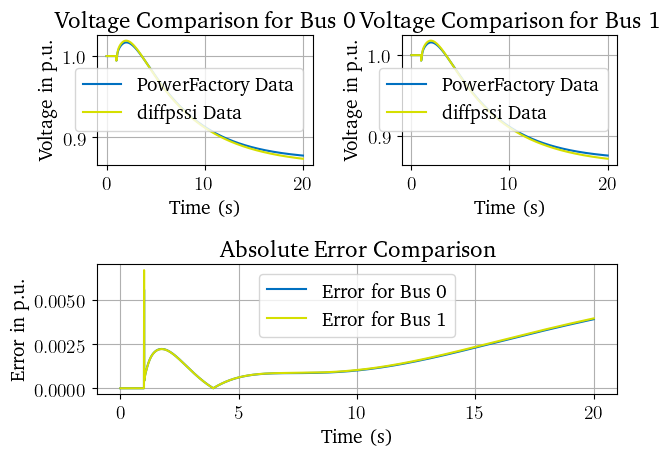

In [11]:
# fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = [plt.subplot(221), plt.subplot(222), plt.subplot(212)]

for i in range(2):
    axs[i].plot(
        data_pf_cZ.index.values, data_pf_cZ.iloc[:, i].values, label="PowerFactory Data"
    )
    axs[i].plot(t, recorder[0, :, i], linestyle="-", label="diffpssi Data")
    axs[i].set_title(f"Voltage Comparison for Bus {i}")
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("Voltage in p.u.")
    axs[i].legend()
    axs[i].grid(True)

# Add mean error plot
for i in range(2):
    axs[2].plot(t, z_errors[:, i], label=f"Error for Bus {i}")

axs[2].set_ylabel("Error in p.u.")
axs[2].set_title("Absolute Error Comparison")
axs[2].set_xlabel("Time (s)")
axs[2].legend()
axs[2].grid(True)

# plt.tight_layout()
# plt.savefig('./data/validation_z-load.pdf')
plt.show()

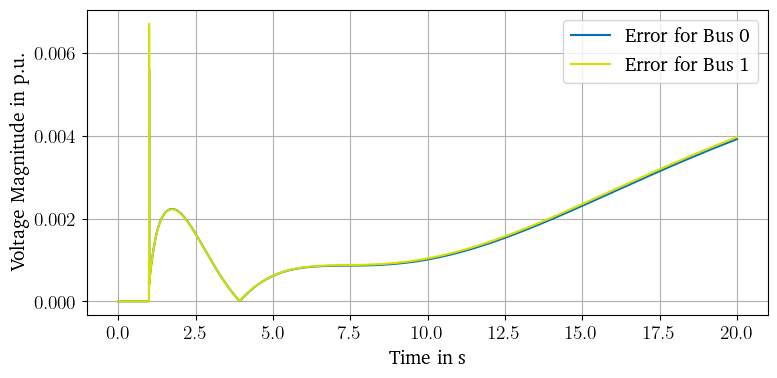

In [12]:
plt.figure(figsize=(8, 4))

plt.plot(t, z_errors[:, 0], label=f"Error for Bus {0}")
plt.plot(t, z_errors[:, 1], label=f"Error for Bus {1}")

plt.grid()
plt.legend()
plt.xlabel("Time in s")
plt.ylabel("Voltage Magnitude in p.u.")

plt.savefig("./data/z_load_error.pdf")
plt.show()

## 2 Looking at a constant I model

### 2.1 Sim Set-Up and Run

In [13]:
theta = [0.9, 1.0, 1.1]
theta_result = []

for ratio in theta:
    sim = Pss(
        parallel_sims=parallel_sims,
        sim_time=5,
        time_step=0.005,
        solver="heun",
        grid_data=load(u_l=ratio),
    )

    sim.add_sc_event(1, 1.05, "Bus 0")
    rec = Recorder(sim=sim, recorder_dict=record_dict)
    sim.set_record_function(rec.record_fun)
    record_list = rec.record_list()
    t, recorder = sim.run()

    theta_result.append(recorder)
    print(f"Current ratio: {sim.trafos[0].u_l}")

    del sim, t, recorder

TypeError: load() got an unexpected keyword argument 'u_l'

In [ ]:
theta_1100 = pd.DataFrame(theta_result[0][0, :, :], columns=record_list)
theta_1100["t"] = time
theta_1100.set_index("t", inplace=True)

theta_2200 = pd.DataFrame(theta_result[1][0, :, :], columns=record_list)
theta_2200["t"] = time
theta_2200.set_index("t", inplace=True)

theta_4400 = pd.DataFrame(theta_result[2][0, :, :], columns=record_list)
theta_4400["t"] = time
theta_4400.set_index("t", inplace=True)

### 2.2 Inspection

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, result in enumerate(theta_result):
    for j in range(3):
        axs[i].plot(time, result[0, :, j], label=record_list[j])
    axs[i].set_title(f"Longitudinal Ratio: {theta[i]}", fontdict={"fontsize": 10})
    axs[i].grid()
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Voltage magnitude [p.u.]")
fig.suptitle(r"Bus voltages for different transformer ratios $\underline{\vartheta}$")

plt.tight_layout()
plt.show()

### 2.3 Loading PF Data

In [ ]:
data_pf_theta09 = pd.read_csv(
    "./data/variation_theta/ibb_simple-transformer_valid_th09.csv", sep=";", dtype=float
)
data_pf_theta09.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_theta09.set_index("t", inplace=True)
data_pf_theta10 = pd.read_csv(
    "./data/variation_sn/ibb_simple-transformer_valid_sn4400.csv", sep=";", dtype=float
)
data_pf_theta10.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_theta10.set_index("t", inplace=True)

data_pf_theta11 = pd.read_csv(
    "./data/variation_theta/ibb_simple-transformer_valid_th11.csv", sep=";", dtype=float
)
data_pf_theta11.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_theta11.set_index("t", inplace=True)

pf_theta_result = [data_pf_theta09, data_pf_theta10, data_pf_theta11]

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, result in enumerate(pf_theta_result):
    for j in range(3):
        axs[i].plot(result.index.values, result.iloc[:, j], label=result.columns[j])
    axs[i].set_title(f"Longitudinal Ratio: {theta[i]}", fontdict={"fontsize": 10})
    axs[i].grid()
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Voltage magnitude [p.u.]")
fig.suptitle(
    r"Bus voltages for different transformer ratios $\underline{\vartheta}$ - PowerFactory"
)

plt.tight_layout()
plt.show()

### 2.4 Comparison

In [ ]:
# Calculate mean error for each theta
theta_errors = np.zeros((3, len(time), 3))
theta_mean_errors = np.zeros(3)
theta_error_lf = np.zeros((3, 3))

for i in range(3):
    ext_voltages = pf_theta_result[i].values
    model_voltage = theta_result[i][0, :, :]
    errors = np.abs(ext_voltages - model_voltage)
    theta_errors[i, :, :] = errors
    theta_mean_errors[i] = np.mean(errors)

for i, error in enumerate(theta_mean_errors):
    print(f"Mean error for theta = {theta[i]}: {np.round(error, 4)*100} %")

for i in range(3):
    for j in range(3):
        theta_error_lf[i, j] = theta_errors[i, 0, j]

    print(
        f"Initial value error for theta = {theta[i]}: {np.round(theta_error_lf[i,:], 4)*100} %"
    )

## 3 Looking at a constant P model

### 3.1 Sim Set-Up and Run

In [ ]:
x1 = [0.15, 0.30, 0.60]
x1_result = []

for x in x1:
    sim = Pss(
        parallel_sims=parallel_sims,
        sim_time=5,
        time_step=0.005,
        solver="heun",
        grid_data=load(x1=x),
    )

    sim.add_sc_event(1, 1.05, "Bus 0")
    rec = Recorder(sim=sim, recorder_dict=record_dict)
    sim.set_record_function(rec.record_fun)
    record_list = rec.record_list()
    t, recorder = sim.run()

    x1_result.append(recorder)
    print(f"Current x1: {sim.trafos[0].x}")

    del sim, t, recorder

In [ ]:
x1_015 = pd.DataFrame(x1_result[0][0, :, :], columns=record_list)
x1_015["t"] = time
x1_015.set_index("t", inplace=True)

x1_030 = pd.DataFrame(x1_result[1][0, :, :], columns=record_list)
x1_030["t"] = time
x1_030.set_index("t", inplace=True)

x1_060 = pd.DataFrame(x1_result[2][0, :, :], columns=record_list)
x1_060["t"] = time
x1_060.set_index("t", inplace=True)

### 3.2 Inspection

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, result in enumerate(x1_result):
    for j in range(3):
        axs[i].plot(time, result[0, :, j], label=record_list[j])
    axs[i].set_title(f"Transformer Reactance: {x1[i]} p.u.", fontdict={"fontsize": 10})
    axs[i].grid()
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Voltage magnitude [p.u.]")
fig.suptitle(r"Bus voltages for different transformer reactances $x_1$")

plt.tight_layout()
plt.show()

### 3.3 Loading PF Data

In [ ]:
data_pf_x1_015 = pd.read_csv(
    "./data/variation_x1/ibb_simple-transformer_valid_x1015.csv", sep=";", dtype=float
)
data_pf_x1_015.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_x1_015.set_index("t", inplace=True)

data_pf_x1_030 = pd.read_csv(
    "./data/variation_x1/ibb_simple-transformer_valid_x1030.csv", sep=";", dtype=float
)
data_pf_x1_030.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_x1_030.set_index("t", inplace=True)

data_pf_x1_060 = pd.read_csv(
    "./data/variation_x1/ibb_simple-transformer_valid_x1060.csv", sep=";", dtype=float
)
data_pf_x1_060.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf_x1_060.set_index("t", inplace=True)

pf_x1_result = [data_pf_x1_015, data_pf_x1_030, data_pf_x1_060]

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, result in enumerate(pf_x1_result):
    for j in range(3):
        axs[i].plot(result.index.values, result.iloc[:, j], label=result.columns[j])
    axs[i].set_title(f"Transformer Reactance: {x1[i]} p.u.", fontdict={"fontsize": 10})
    axs[i].grid()
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Voltage magnitude [p.u.]")
fig.suptitle(r"Bus voltages for different transformer reactances $x_1$ - PowerFactory")

plt.tight_layout()
plt.show()

### 3.4 Comparison

In [ ]:
# Calculate mean error for each theta
x1_errors = np.zeros((3, len(time), 3))
x1_mean_errors = np.zeros(3)
x1_error_lf = np.zeros((3, 3))

for i in range(3):
    ext_voltages = pf_x1_result[i].values
    model_voltage = x1_result[i][0, :, :]
    errors = np.abs(ext_voltages - model_voltage)
    x1_errors[i, :, :] = errors
    x1_mean_errors[i] = np.mean(errors)

for i, error in enumerate(x1_mean_errors):
    print(f"Mean error for x1 = {x1[i]}: {np.round(error, 4)*100} %")

for i in range(3):
    for j in range(3):
        x1_error_lf[i, j] = x1_errors[i, 0, j]

    print(
        f"Initial value error for x1 = {x1[i]}: {np.round(x1_error_lf[i,:], 4)*100} %"
    )